<a href="https://colab.research.google.com/github/tifli/142a-project/blob/main/IOER_Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Import Packages

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.model_selection import train_test_split, cross_val_score, KFold, LeaveOneOut
from sklearn.linear_model import LinearRegression

In [ ]:
K_FOLDS = 5
RANDOM_STATE = 42
TEST_SIZE = 0.2

##Import Dataset

In [ ]:
url = "https://raw.githubusercontent.com/tifli/142a-project/refs/heads/main/university_ranking.csv"
df = pd.read_csv(url)
df = df[df['year'] >= 2016]

# List of columns that should be numeric but might contain commas or percent signs
cols_to_clean = ['No. of FTE students', 'No. of students per staff',
                 'International students', 'International Outlook', 'Industry']

for col in cols_to_clean:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col].astype(str).str.replace(',', '').str.replace('%', '').str.replace('-', ''), errors='coerce')

X = df.drop(['Female:Male ratio', 'rank_prefix', 'Industry'], axis=1)
y = df['Industry']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)

train_data = pd.concat([X_train, y_train], axis=1)
test_data = pd.concat([X_test, y_test], axis=1)

# Drop NaNs if any were created in the target variable
train_data = train_data.dropna(subset=['Industry'])
test_data = test_data.dropna(subset=['Industry'])

##Define Functions for Model Evaluations

In [ ]:
# compute out-of-sample R-squared using the test set
def OSR2(model, df_train, df_test, dependent_var):
    y_test = df_test[dependent_var]
    y_pred = model.predict(df_test)
    SSE = np.sum((y_test - y_pred)**2)
    SST = np.sum((y_test - np.mean(df_train[dependent_var]))**2)
    return 1 - SSE/SST

In [ ]:
# compute out-of-sample R-squared using the test set
def OSR2_alt(model, df_train, df_test, category_var, dependent_var, features):

    # Use drop_first=False to generate all dummies, then align to model columns
    # This prevents dropping a category that might be the reference in the test
    # set but not the train set
    df_test_encoded = pd.get_dummies(
        df_test[features],
        columns=[category_var],
        drop_first=False,
        dtype=float
    )

    df_test_encoded = sm.add_constant(df_test_encoded)

    # Align columns with the training data features (model parameters)
    # This adds missing columns (filled with 0) and removes extra ones
    df_test_encoded = df_test_encoded.reindex(columns=model.params.index,
                                              fill_value=0)

    y_test = df_test[dependent_var]
    y_pred = model.predict(df_test_encoded)
    SSE = np.sum((y_test - y_pred)**2)
    SST = np.sum((y_test - np.mean(df_train[dependent_var]))**2)
    return 1 - SSE/SST

##Linear Regression

####Without "Name" column

In [ ]:
ols = smf.ols(formula='Industry ~ Rank + Q("No. of FTE students") + Q("No. of students per staff") + Q("International students") + Overall + Teaching + Q("Research Environment") + Q("Research Quality") + Q("International Outlook")',
                 data=train_data)
model1 = ols.fit()
print(model1.summary())

osr_reduced = OSR2(model1, train_data, test_data, 'Industry')
print()
print(f"OSR-squared (reduced model): {osr_reduced}")

                            OLS Regression Results                            
Dep. Variable:               Industry   R-squared:                       0.941
Model:                            OLS   Adj. R-squared:                  0.941
Method:                 Least Squares   F-statistic:                     3000.
Date:                Thu, 30 Apr 2026   Prob (F-statistic):               0.00
Time:                        04:46:48   Log-Likelihood:                -5307.2
No. Observations:                1696   AIC:                         1.063e+04
Df Residuals:                    1686   BIC:                         1.069e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept   

####With "Name" column

*Use one-hot encoding*

In [ ]:
features = ['Name', 'Rank', 'No. of FTE students', 'No. of students per staff',
            'International students','Overall', 'Teaching',
            'Research Environment', 'Research Quality', 'International Outlook']
category_var = 'Name'

train_data_encode = pd.get_dummies(
    train_data[features],
    columns=[category_var],
    drop_first=True,
    dtype=float
)

train_data_encode = sm.add_constant(train_data_encode)

depend = train_data['Industry']
model_encode = sm.OLS(depend, train_data_encode).fit()

# Print the first 30 lines of the summary using str()
summary_str = str(model_encode.summary())
print('\n'.join(summary_str.split('\n')[:30]))

osr_full = OSR2_alt(model_encode, train_data, test_data, category_var, 'Industry', features)
print()
print(f"OSR-squared (full model): {osr_full}")

                            OLS Regression Results                            
Dep. Variable:               Industry   R-squared:                       0.968
Model:                            OLS   Adj. R-squared:                  0.962
Method:                 Least Squares   F-statistic:                     163.2
Date:                Thu, 30 Apr 2026   Prob (F-statistic):               0.00
Time:                        04:46:48   Log-Likelihood:                -4788.1
No. Observations:                1696   AIC:                         1.011e+04
Df Residuals:                    1429   BIC:                         1.156e+04
Df Model:                         266                                         
Covariance Type:            nonrobust                                         
                                                                      coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------

**Summary**

Note that both the R-squared and OSR-squared values for the full model above (with "Name") are higher than the reduced model (without "Name"). Hence, we should keep the universities' names in the final model for more accurate predictions.

## Ridge Regression

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV, RidgeCV

# One-hot encode the categorical 'Name' column for both sets
X_train_encoded = pd.get_dummies(X_train, columns=['Name'], drop_first=True, dtype=float)
X_test_encoded = pd.get_dummies(X_test, columns=['Name'], drop_first=False, dtype=float)

# Align columns to ensure the test set has the exact same dummy features as the train set
X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

loocv = LeaveOneOut()
ridge_cv = RidgeCV(cv=loocv, scoring='neg_mean_squared_error').fit(X_train_scaled, y_train)

print(f"Best lambda: {ridge_cv.alpha_}")

y_pred_l2 = ridge_cv.predict(X_test_scaled)
SSE = np.sum((y_test - y_pred_l2)**2)
SST = np.sum((y_test - np.mean(y_train))**2)
OSR2_l2 = 1 - (SSE/SST)

print(f"OSR2 = {OSR2_l2}")

print("\nFirst 20 Regression coefficients:")
ridge_coefs = pd.Series(ridge_cv.coef_, index=X_train_encoded.columns)
print(ridge_coefs.head(20))

Best lambda: 0.1
OSR2 = 0.9613754526968764

First 20 Regression coefficients:
year                                       1.670551
Rank                                      -4.513992
No. of FTE students                        2.355550
No. of students per staff                  2.754649
International students                    -0.834649
Overall                                  260.174692
Teaching                                -115.182107
Research Environment                    -123.785926
Research Quality                         -79.704484
International Outlook                    -29.362738
Name_Aalto University                     -0.141995
Name_Aarhus University                    -0.053805
Name_Abu Dhabi University                 -0.040505
Name_Adelaide University                  -0.272963
Name_Arizona State University (Tempe)     -0.810808
Name_Australian National University       -0.558527
Name_Beijing Normal University            -0.064114
Name_Bielefeld University             

,Feature,OLS,Ridge
0,year,1.075693,1.670551
1,Rank,-6.190391,-4.513992
2,No. of FTE students,2.094254,2.355550
3,No. of students per staff,2.784681,2.754649
4,International students,-0.646906,-0.834649
5,Overall,292.394770,260.174692
6,Teaching,-131.252771,-115.182107
7,Research Environment,-140.232956,-123.785926
8,Research Quality,-90.316846,-79.704484
9,International Outlook,-33.501076,-29.362738


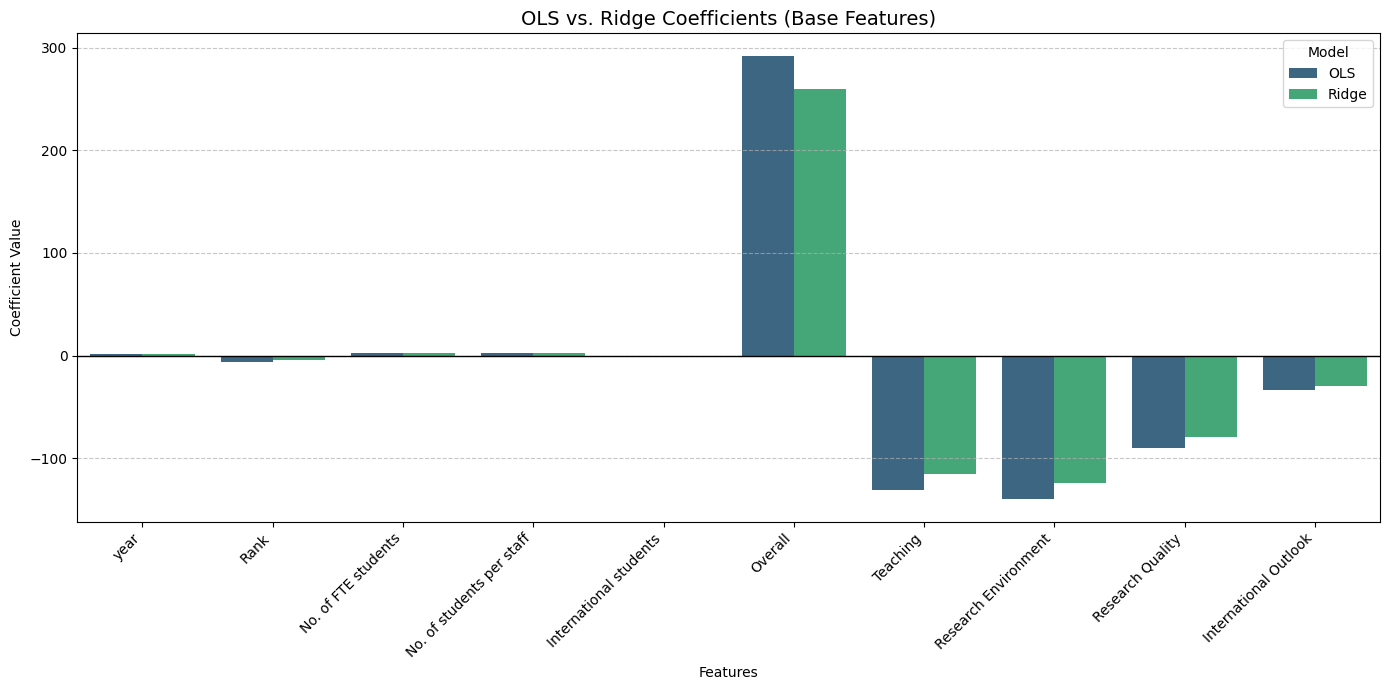

In [50]:
# Fit standard OLS on the scaled data for a fair comparison with Ridge
from sklearn.linear_model import LinearRegression

ols_scaled = LinearRegression().fit(X_train_scaled, y_train)

# Create a DataFrame with the features and their corresponding coefficients
coef_df = pd.DataFrame({
    'Feature': X_train_encoded.columns,
    'OLS': ols_scaled.coef_,
    'Ridge': ridge_cv.coef_
})

# Display the top coefficients table (to avoid a massive table)
display(coef_df.head(15))

# To keep the plot readable, filter down to just the original numeric features
numeric_cols = [c for c in X_train_encoded.columns if not c.startswith('Name_')]
coef_df_numeric = coef_df[coef_df['Feature'].isin(numeric_cols)]

# Melt the DataFrame to make it compatible with Seaborn's hue parameter
coef_df_melted = coef_df_numeric.melt(id_vars='Feature', var_name='Model', value_name='Coefficient')

# Plotting
plt.figure(figsize=(14, 7))
sns.barplot(data=coef_df_melted, x='Feature', y='Coefficient', hue='Model', palette='viridis')
plt.axhline(0, color='black', linewidth=1)
plt.xticks(rotation=45, ha='right')
plt.title('OLS vs. Ridge Coefficients (Base Features)', fontsize=14)
plt.ylabel('Coefficient Value')
plt.xlabel('Features')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Model')
plt.tight_layout()
plt.show()

**Note**

Since none of the regression coefficients are close to zero, all of the features are important for the model. Thus, we must use PCA to combine features that are highly correlated with each. In this case, they are most likely 'Overall', 'Research Environment', and (possibly) 'Teaching'.

##PCA

In [ ]:
from sklearn.decomposition import PCA

# Use the one-hot encoded dataset to include categorical variables
X_train_pca_input = X_train_encoded

# Candidate numbers of principal components (limit to 50 for performance)
max_components = min(X_train_pca_input.shape[1], 50)
component_grid = list(range(1, max_components + 1, 2))

# K-fold CV object (Use KFold instead of StratifiedKFold for continuous targets)
kf = KFold(n_splits=K_FOLDS, shuffle=True, random_state=RANDOM_STATE)

cv_scores = {}

for k in component_grid:
    fold_R_sq = []

    for train_idx, val_idx in kf.split(X_train_pca_input):
        # Split the training data into one training fold and one validation fold
        X_tr = X_train_pca_input.iloc[train_idx]
        X_val = X_train_pca_input.iloc[val_idx]
        y_tr = y_train.iloc[train_idx]
        y_val = y_train.iloc[val_idx]

        # Fit PCA only on the training fold
        pca = PCA(n_components=k)
        X_tr_pca = pca.fit_transform(X_tr)
        X_val_pca = pca.transform(X_val)

        # Fit linear regression on the PCA-transformed training fold
        lr = LinearRegression()
        lr.fit(X_tr_pca, y_tr)

        # Predict on the validation fold
        R = lr.score(X_val_pca, y_val)
        fold_R_sq.append(R)

    # Store the mean CV R-squared for this k
    cv_scores[k] = np.mean(fold_R_sq)
    print(f"k = {k:2d}, mean = {cv_scores[k]:.4f}")

k =  1, mean = -0.0056
k =  3, mean = 0.0244
k =  5, mean = 0.1411
k =  7, mean = 0.1681
k =  9, mean = 0.4186
k = 11, mean = 0.9448
k = 13, mean = 0.9447
k = 15, mean = 0.9447
k = 17, mean = 0.9447
k = 19, mean = 0.9445
k = 21, mean = 0.9445
k = 23, mean = 0.9443
k = 25, mean = 0.9442
k = 27, mean = 0.9441
k = 29, mean = 0.9443
k = 31, mean = 0.9438
k = 33, mean = 0.9439
k = 35, mean = 0.9438
k = 37, mean = 0.9434
k = 39, mean = 0.9439
k = 41, mean = 0.9434
k = 43, mean = 0.9433
k = 45, mean = 0.9432
k = 47, mean = 0.9431
k = 49, mean = 0.9433


In [ ]:
# Choose the best number of components
best_k = max(cv_scores, key=cv_scores.get)
print("\nBest number of principal components:", best_k)
print("Best mean CV R-squared:", cv_scores[best_k])


Best number of principal components: 11
Best mean CV R-squared: 0.9447854893434663


In [ ]:
# Refit on the full training set using best_k
pca_best = PCA(n_components=best_k)
X_train_pca_best = pca_best.fit_transform(X_train_encoded)
X_test_pca_best = pca_best.transform(X_test_encoded)

lr_best = LinearRegression()
lr_best.fit(X_train_pca_best, y_train)

train_R_sq = lr_best.score(X_train_pca_best, y_train)
test_R_sq = lr_best.score(X_test_pca_best, y_test)

print("\nFinal model results")
print("Train R-squared:", round(train_R_sq, 4))
print("Test R-squared :", round(test_R_sq, 4))


Final model results
Train R-squared: 0.9458
Test R-squared : 0.9519


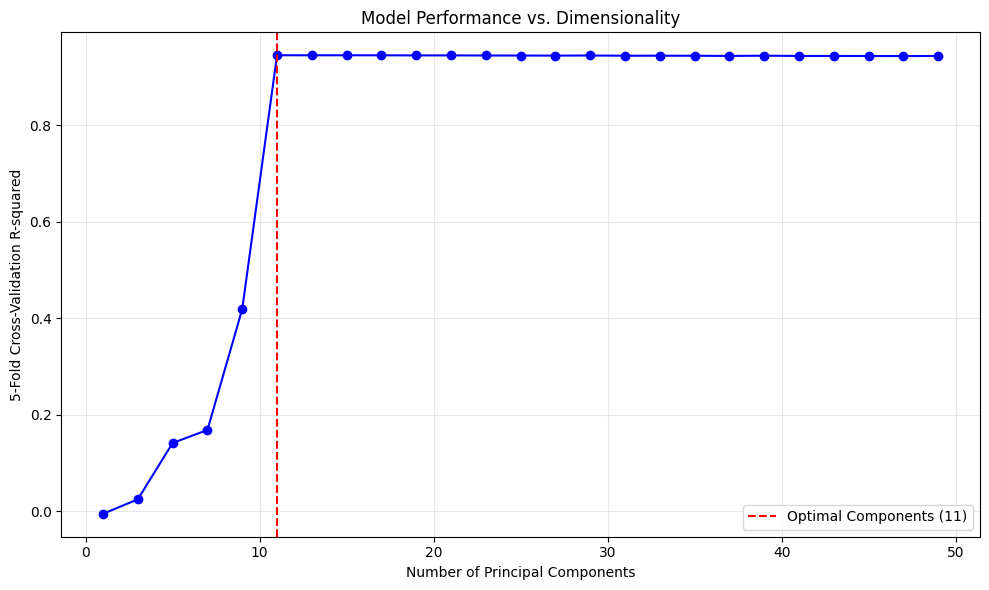

In [ ]:
# --- VISUALIZATION: Cross-Validation R-squared Curve ---
mean_test_scores = [cv_scores[k] for k in component_grid]

plt.figure(figsize=(10, 6))
plt.plot(component_grid, mean_test_scores, marker='o', linestyle='-', color='b')
plt.axvline(x=best_k, color='r', linestyle='--', label=f'Optimal Components ({best_k})')
plt.xlabel('Number of Principal Components')
plt.ylabel(f'5-Fold Cross-Validation R-squared')
plt.title('Model Performance vs. Dimensionality')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()